# Simple GAN by fasion image Chapter 14 Workshop 2

## Import module

In [28]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import Callback
import numpy as np
import matplotlib.pyplot as plt
import os
import gdown
from zipfile import ZipFile

In [11]:
# !rm -rf /celeba_gan/img_align_celeba

## Create folder and download zip file

In [12]:
# os.makedirs("celeba_gan")

# url = "https://drive.google.com/uc?id=1O7m1010EJjLE5QxLZiM9FpjsOj6e684"
# url = "https://drive.google.com/uc?id=1O7m1010EJjLE5QxLZiM9FpjsOj6e684"
# output = "celeba_gan/data.zip"
# gdown.download(url, output, quiet=True)

data_dir = "drive/MyDrive/deep_learning_file/data.zip"

with ZipFile(data_dir, "r") as zipobj:
    zipobj.extractall("celeba_gan")

## Load dataset

In [5]:
dataset = keras.preprocessing.image_dataset_from_directory(
    "celeba_gan", label_mode=None, image_size=(64, 64), batch_size=32
)

dataset = dataset.map(lambda x: x/255.0)

Found 202599 files.


## Plot dataset

### 1 image

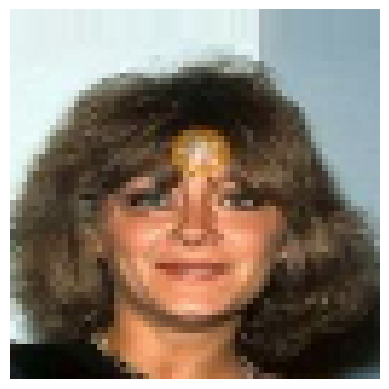

In [13]:
for x in dataset:
  plt.axis("off")
  plt.imshow(x[0])
  break

### many image

In [15]:
del zip

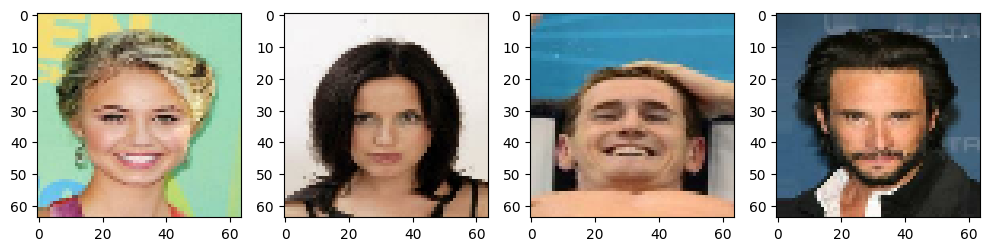

In [16]:
def plotImages(images_arr):
  fig, axes = plt.subplots(1, 4, figsize=(10, 10))
  for img, ax in zip(images_arr, axes):
    ax.imshow(img)
  plt.tight_layout()
  plt.show()

iterator = iter(dataset)
img_samples = next(iterator)
plotImages(img_samples[:4])

## Create model

### Discriminator

In [17]:
# 64x64x3 -> 32x32x64 -> 16x16x128 -> 8x8x128 -> 8192 -> [0,1]
discriminator = keras.Sequential(
    [
        keras.Input(shape=(64, 64, 3)),
        layers.Conv2D(64, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Flatten(),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="discriminator",
)
discriminator.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,801 (1.54 MB)

 Trainable params: 404,801 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

### Generator

In [18]:
latent_dim = 128

# 128 -> 8192 -> 8x8x128 -> 16x16x128 -> 32x32x256 -> 64x64x512 -> 64x64x3
generator = keras.Sequential(
    [
        keras.Input(shape=(latent_dim,)),
        layers.Dense(8 * 8 * 128),
        layers.Reshape((8, 8, 128)),
        layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2DTranspose(256, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2DTranspose(512, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(3, kernel_size=5, padding="same", activation="sigmoid"),
    ],
    name="generator",
)
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 8192)           │     1,056,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 256)    │       524,544 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 512)    │     2,097,664 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 64, 64, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 3)      │        38,403 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,979,651 (15.18 MB)

 Trainable params: 3,979,651 (15.18 MB)

 Non-trainable params: 0 (0.00 B)

### GAN

In [19]:
class GAN(keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super(GAN, self).__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super(GAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn
        self.d_loss_metric = keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")
    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):
        # random value for latent space
        batch_size = tf.shape(real_images)[0]
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))

        # create fake image (Decode)
        generated_images = self.generator(random_latent_vectors)

        # collect image (fake image and real image)
        combined_images = tf.concat([generated_images, real_images], axis=0)

        # label for fake and real image
        labels = tf.concat(
            [tf.ones((batch_size, 1)), tf.zeros((batch_size, 1))], axis=0
        )

        # put random noise in label
        labels += 0.05 * tf.random.uniform(tf.shape(labels))

        # Train Discriminator
        with tf.GradientTape() as tape:
            predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, predictions)
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(
            zip(grads, self.discriminator.trainable_weights)
        )

        # random value for latent space
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))

        # label for real image
        misleading_labels = tf.zeros((batch_size, 1))

        # Train generator (Discriminator will not be updated)
        with tf.GradientTape() as tape:
            predictions = self.discriminator(self.generator(random_latent_vectors))
            g_loss = self.loss_fn(misleading_labels, predictions)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        # Update loss
        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)
        return{
            "d_loss": self.d_loss_metric.result(),
            "g_loss": self.g_loss_metric.result(),
        }

In [26]:
class GANMonitor(keras.callbacks.Callback):
    def __init__(self, num_img=3, latent_dim=128):
        self.num_img = num_img
        self.latent_dim = latent_dim

    def on_epoch_end(self, epoch, logs=None):
        random_latent_vectors = tf.random.normal(shape=(self.num_img, self.latent_dim))
        generated_images = self.model.generator(random_latent_vectors)
        generated_images = (generated_images * 255).numpy().astype("int32")
        # generated_images.numpy()
        for i in range(self.num_img):
            img = keras.preprocessing.image.array_to_img(generated_images[i])
            img.save("generated_img_{i}_{epoch}.png".format(i=i, epoch=epoch))
epochs = 1
gan = GAN(discriminator=discriminator, generator=generator, latent_dim=latent_dim)
gan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss_fn=keras.losses.BinaryCrossentropy(),
)

In [29]:
class BestGeneratorSaver(Callback):
    def __init__(self, generator, monitor='g_loss', save_path='best_generator.h5'):
        self.generator = generator
        self.monitor = monitor
        self.save_path = save_path
        self.best = float('inf')

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get(self.monitor)
        if current is not None and current < self.best:
            print(f"🔼 g_loss improved from {self.best:.4f} to {current:.4f}. Saving model.")
            self.best = current
            self.generator.save(self.save_path)

In [25]:
epochs = 1
model_save_path = "drive/MyDrive/deep_learning_file/best_generator.h5"
gan.fit(
    dataset, epochs=epochs, callbacks=[
        GANMonitor(num_img=10, latent_dim=latent_dim,),
        BestGeneratorSaver(gan.generator,save_path=model_save_path)]
)

6332/6332 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - d_loss: 0.6440 - g_loss: 1.0890

AttributeError: 'numpy.ndarray' object has no attribute 'numpy'

Exception ignored in: <function _xla_gc_callback at 0x7d4e216e22a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/jax/_src/lib/__init__.py", line 96, in _xla_gc_callback
    def _xla_gc_callback(*args):
    
KeyboardInterrupt: 


## Visualization

### Define function

In [31]:
def visualize_images(images, n=10):
    """Visualize a grid of images."""
    plt.figure(figsize=(n, n))
    for i in range(n * n):
        plt.subplot(n, n, i + 1)
        plt.imshow(images[i].reshape(img_rows, img_cols), cmap='gray_r')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def show_images(noise, sizefig, generator):
    genereated_images = generator.predict(noise)
    plt.figure(figsize=(sizefig[1], sizefig[0]))
    out_shape = generator.output_shape
    channels = out_shape[-1]
    img_rows = out_shape[1]
    img_cols = out_shape[2]

    for i, image in enumerate(genereated_images):
        plt.subplot(sizefig[0], sizefig[1], i + 1)
        if channels == 1:
            plt.imshow(image.reshape(img_rows, img_cols), cmap='gray_r')
        else:
            plt.imshow(image.reshape(img_rows, img_cols, channels))
        plt.axis('off')
    plt.tight_layout()
    plt.show()

### visualize

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


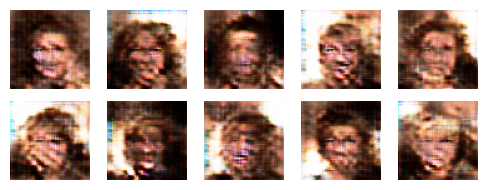

In [32]:
noise = np.random.normal(0, 1, (10, latent_dim))
show_images(noise, (2,5),  gan.generator)


## Save model

In [34]:
model_save_path = "drive/MyDrive/deep_learning_file/best_generator.h5"
gan.generator.save(model_save_path)